In [7]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pretty_midi
from collections import Counter
from melody import (build_rolls, pad_rolls, compute_highest_per_instrument,
                    track_lead_voice, rle, compute_pitch_classes,
                    compute_contour, compute_key_from_pitch_classes)

NAZWA_PLIKU          = 'music/open.mid'
FS                   = 100
MIN_NOTES            = 10
MIN_PITCH            = 48
MIN_ENERGY_PER_FRAME = 10
SWITCH_N             = 3


In [8]:
utwor = pretty_midi.PrettyMIDI(NAZWA_PLIKU)

beats = utwor.get_beats()
beat_frames = (beats * FS).astype(int)
rolls, instruments = build_rolls(utwor, fs=FS, min_notes=MIN_NOTES)
padded, max_len = pad_rolls(rolls)
beat_frames_clipped = np.clip(beat_frames, 0, max_len)
n_windows = len(beat_frames_clipped) - 1
n_inst = len(padded)
highest = compute_highest_per_instrument(padded, beat_frames_clipped, MIN_PITCH, MIN_ENERGY_PER_FRAME)
lead_inst_idx, lead_pitch = track_lead_voice(highest, n_windows, n_inst, SWITCH_N)

Segments:
Pitch 93 from beat 0 to 4
Pitch 69 from beat 4 to 16
Pitch 79 from beat 16 to 19
Pitch 81 from beat 19 to 20
Pitch 69 from beat 20 to 28
Pitch 76 from beat 28 to 30
Pitch 77 from beat 30 to 31
Pitch 76 from beat 31 to 32
Pitch 74 from beat 32 to 36
Pitch 81 from beat 39 to 40
Pitch 79 from beat 40 to 41
Pitch 75 from beat 41 to 42
Pitch 74 from beat 42 to 44
Pitch 67 from beat 44 to 45
Pitch 70 from beat 45 to 46
Pitch 72 from beat 46 to 47
Pitch 82 from beat 47 to 48
Pitch 81 from beat 48 to 49
Pitch 78 from beat 49 to 50
Pitch 79 from beat 50 to 52
Pitch 79 from beat 55 to 56
Pitch 74 from beat 56 to 57
Pitch 75 from beat 57 to 58
Pitch 74 from beat 58 to 60
Pitch 67 from beat 60 to 61
Pitch 70 from beat 61 to 62
Pitch 72 from beat 62 to 63
Pitch 82 from beat 63 to 64
Pitch 81 from beat 64 to 65
Pitch 78 from beat 65 to 66
Pitch 79 from beat 66 to 67
Pitch 76 from beat 67 to 68
Pitch 83 from beat 71 to 75
Pitch 76 from beat 75 to 76
Pitch 81 from beat 76 to 78
Pitch 84 from

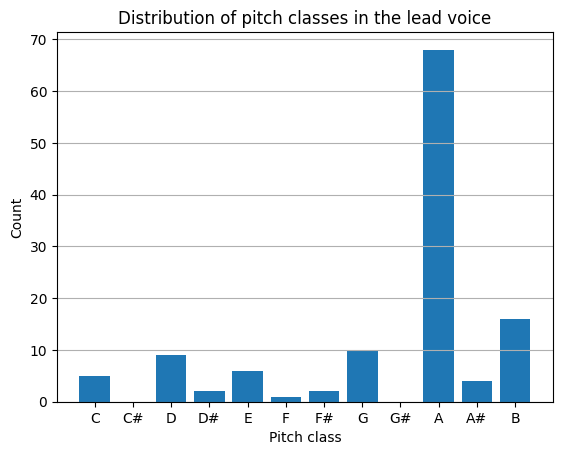

In [9]:
segments = rle(lead_pitch)
print('Segments:')
for pitch, start, end in segments:
    print(f'Pitch {pitch} from beat {start} to {end}')

NOTES = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
pitch_classes = compute_pitch_classes(lead_pitch)
pitch_class_counts = Counter(pitch_classes)
print('Pitch class counts:')
for pc, count in pitch_class_counts.most_common():
    print(f'Pitch class {NOTES[pc]}: {count} occurrences')

plt.hist(pitch_classes, bins=np.arange(13)-0.5, rwidth=0.8)
plt.xticks(np.arange(12), NOTES)
plt.xlabel('Pitch class')
plt.ylabel('Count')
plt.title('Distribution of pitch classes in the lead voice')
plt.grid(axis='y')
plt.show()


In [13]:
print(compute_key_from_pitch_classes(lead_pitch))
major_key, major_corr, minor_key, minor_corr = compute_key_from_pitch_classes(lead_pitch)
print(f'Best major key: {major_key} (r={major_corr:.2f})')
print(f'Best minor key: {minor_key} (r={minor_corr:.2f})')


Best major key: D# with correlation 0.68
Best minor key: D# with correlation 0.71
None
Best major key: D# with correlation 0.68
Best minor key: D# with correlation 0.71


TypeError: cannot unpack non-iterable NoneType object

In [ ]:
contour = compute_contour(lead_pitch)
contour_counts = Counter(contour)
print("Contour counts:")
for c, count in contour_counts.most_common():
    print(f"{c}: {count} occurrences")

# plot contour changes in time
plt.figure(figsize=(12, 4))
plt.scatter(range(len(contour)), contour, marker='o', color='purple')
plt.xlabel("Beat index")
plt.ylabel("Contour")
plt.title("Melodic contour of the lead voice")
plt.grid(True, alpha=0.3)
plt.show()

# step leap ratio
step_count = contour_counts['up'] + contour_counts['down'] + contour_counts['same']
leap_count = contour_counts['leap']
step_leap_ratio = step_count / leap_count if leap_count > 0 else float('inf')
print(f"Step-leap ratio: {step_leap_ratio:.2f}")